# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

## 1. Preprocessing and logreg visualization

Read the file `am_pm.csv` to a dataframe from the previous exercise.

1. Draw a plot where the x-axis is `am`, the y-axis is `pm`, dots are the days, color depends on the target.
2. Add the decision boundary of logistic regression to the plot.
3. Draw the same plot (with the boundary), but the color should depend this time on the predictions.

Now it should be clear for you how the logistic regression works.

In [75]:
df = pd.read_csv("../data/am_pm.csv")

X = df[['am', 'pm']].values
y = df['target'].values

print(df.head())
print(f"\nTarget values: {np.unique(y)}")

         date  am  pm       target  predict
0  2020-04-17  21   2  working_day        0
1  2020-04-18   1  68      weekend        1
2  2020-04-19  18  15      weekend        1
3  2020-04-20   2  23  working_day        1
4  2020-04-21   0  25  working_day        1

Target values: ['weekend' 'working_day']


In [76]:
log_reg_original = LogisticRegression(random_state=21, fit_intercept=False)
log_reg_original.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",False
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",21
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [77]:
df['predict'] = log_reg_original.predict(X)

In [78]:
def plot_decision_boundary(X, y_true, model, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))
    
    h = 0.1
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    
    classes = model.classes_
    class_to_int = {cls: i for i, cls in enumerate(classes)}
    Z_numeric = np.array([class_to_int[p] for p in Z])
    Z_numeric = Z_numeric.reshape(xx.shape)
    

    if isinstance(y_true, pd.Series):
        y_true = y_true.values

    if np.issubdtype(np.asarray(y_true).dtype, np.number):
        y_numeric = np.asarray(y_true, dtype=float)
    else:
        y_numeric = np.array([class_to_int[val] for val in y_true])
    
    ax.contourf(xx, yy, Z_numeric, alpha=0.3, cmap='vanimo')
    ax.scatter(X[:, 0], X[:, 1], c=y_numeric, cmap='vanimo', 
               edgecolors='k', linewidth=0.5)
    ax.set_xlabel('Number of commits before midday (AM)')
    ax.set_ylabel('Number of commits after midday (PM)')
    ax.set_title(title)
    return ax

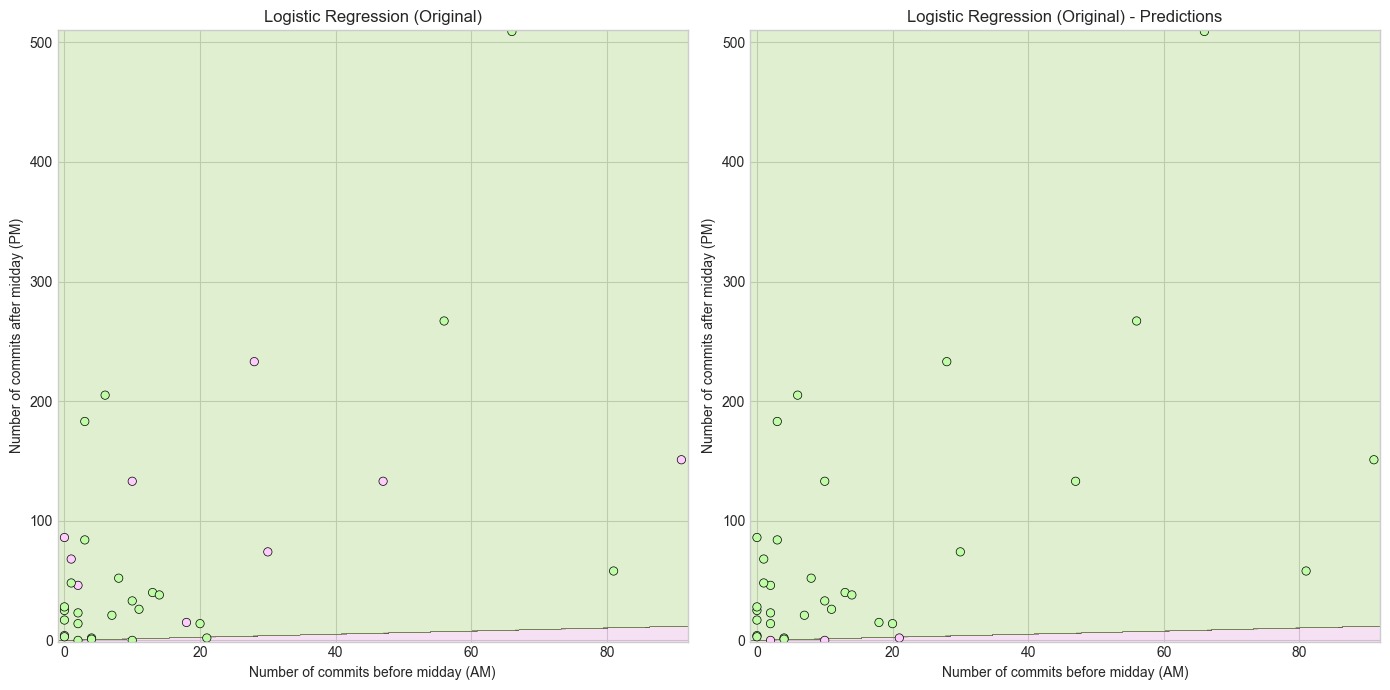

In [79]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

plot_decision_boundary(X, y, log_reg_original, 
                       "Logistic Regression (Original)", ax=ax1)
plot_decision_boundary(X, df['predict'].values, log_reg_original,
                       "Logistic Regression (Original) - Predictions", ax=ax2)

plt.tight_layout()
plt.show()

## 2. Standardizing and logreg

Linear models can be sensitive to the scale of your variables. You make it easier for them to find the optimal solution when you scale your features.

1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.
2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?
3. Draw the plots that were described above but for the new model.

In [80]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

log_reg_scaled = LogisticRegression(random_state=21, fit_intercept=False)
log_reg_scaled.fit(X_scaled, y)

df['predict_scaled'] = log_reg_scaled.predict(X_scaled)

In [81]:
accuracy_scaled = accuracy_score(y, df['predict_scaled'])
print(f"Accuracy with scaling: {accuracy_scaled:.4f}")

Accuracy with scaling: 0.7429


In [82]:
majority_class = np.bincount(np.unique(y, return_inverse=True)[1]).argmax()
naive_accuracy = np.mean(np.unique(y, return_inverse=True)[1] == majority_class)
print(f"Naive baseline accuracy: {naive_accuracy:.4f}")

Naive baseline accuracy: 0.7143


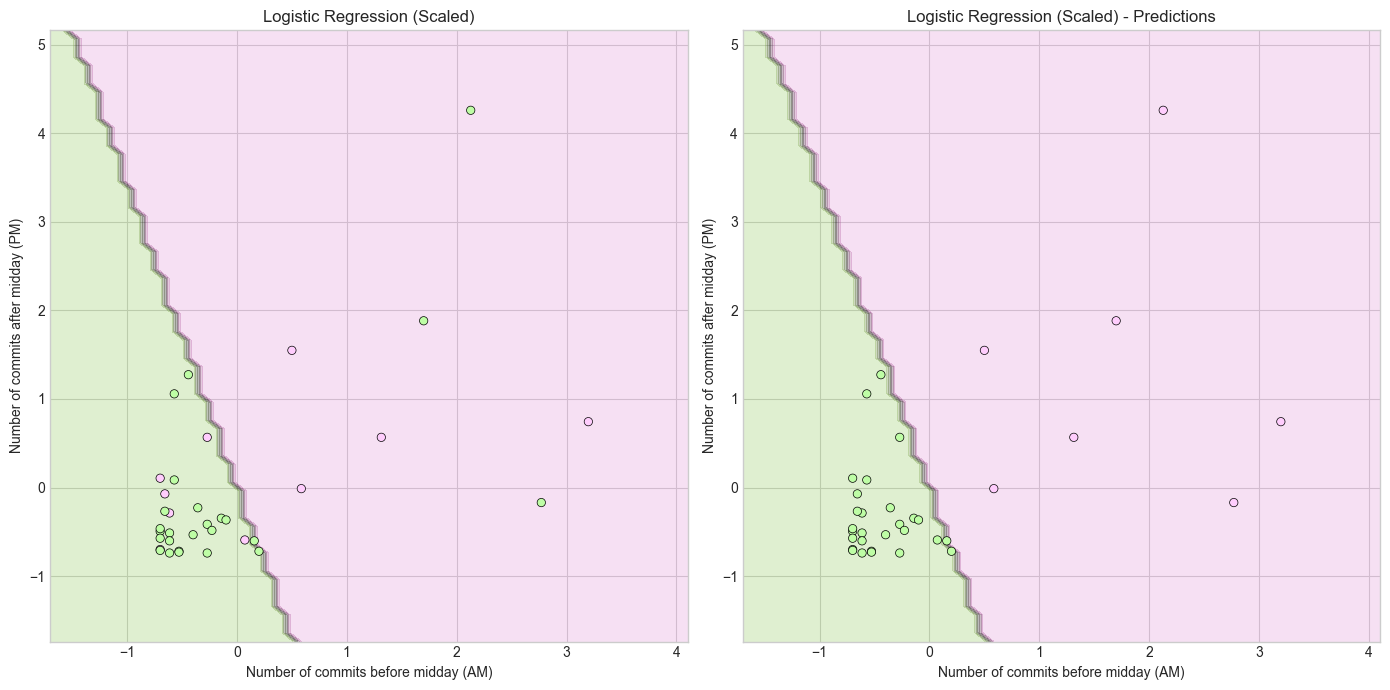

In [83]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

plot_decision_boundary(X_scaled, y, log_reg_scaled,
                       "Logistic Regression (Scaled)", ax=ax1)
plot_decision_boundary(X_scaled, df['predict_scaled'].values, log_reg_scaled,
                       "Logistic Regression (Scaled) - Predictions", ax=ax2)

plt.tight_layout()
plt.show()

## 3. SVM

1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.
2. Calculate `accuracy`.
3. Try different kernels, find the best in terms of accuracy.
4. Draw both plots again with the decisions boundary to see how this algorithm works.

In [84]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
best_accuracy = 0
best_svm = None
best_kernel = None

for kernel in kernels:
    svm = SVC(kernel=kernel, probability=True, random_state=21)
    svm.fit(X_scaled, y)
    acc = accuracy_score(y, svm.predict(X_scaled))
    print(f"Kernel: {kernel:7} Accuracy: {acc:.4f}")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_svm = svm
        best_kernel = kernel

Kernel: linear  Accuracy: 0.7143
Kernel: poly    Accuracy: 0.7429
Kernel: rbf     Accuracy: 0.7429
Kernel: sigmoid Accuracy: 0.6857


In [85]:
print(f"\nBest kernel: {best_kernel} with accuracy {best_accuracy:.4f}")


Best kernel: poly with accuracy 0.7429


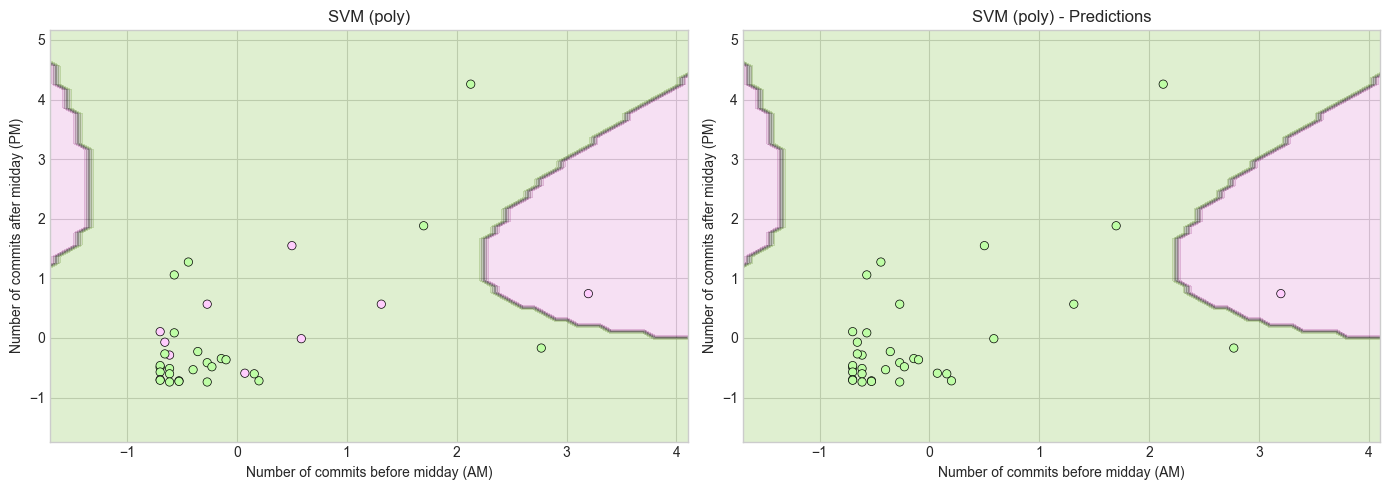

In [86]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_decision_boundary(X_scaled, y, best_svm,
                       f"SVM ({best_kernel})", ax=ax1)
plot_decision_boundary(X_scaled, best_svm.predict(X_scaled), best_svm,
                       f"SVM ({best_kernel}) - Predictions", ax=ax2)

plt.tight_layout()
plt.show()

## 4. Decision tree

1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.
2. Calculate accuracy.
3. Try different values of `max_depth`.
4. Draw both plots again with the decisions boundary to see how this algorithm works.
5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.
6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

In [87]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_scaled, y)
print(f"Decision Tree (max_depth=4) Accuracy: {accuracy_score(y, dt.predict(X_scaled)):.4f}")

Decision Tree (max_depth=4) Accuracy: 0.9429


In [88]:
print("\nExploring different depths:")
for depth in [2, 3, 4, 5, 6]:
    dt_test = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_test.fit(X_scaled, y)
    acc = accuracy_score(y, dt_test.predict(X_scaled))
    print(f"max_depth={depth}, Accuracy: {acc:.4f}")


Exploring different depths:
max_depth=2, Accuracy: 0.8571
max_depth=3, Accuracy: 0.8857
max_depth=4, Accuracy: 0.9429
max_depth=5, Accuracy: 0.9714
max_depth=6, Accuracy: 1.0000


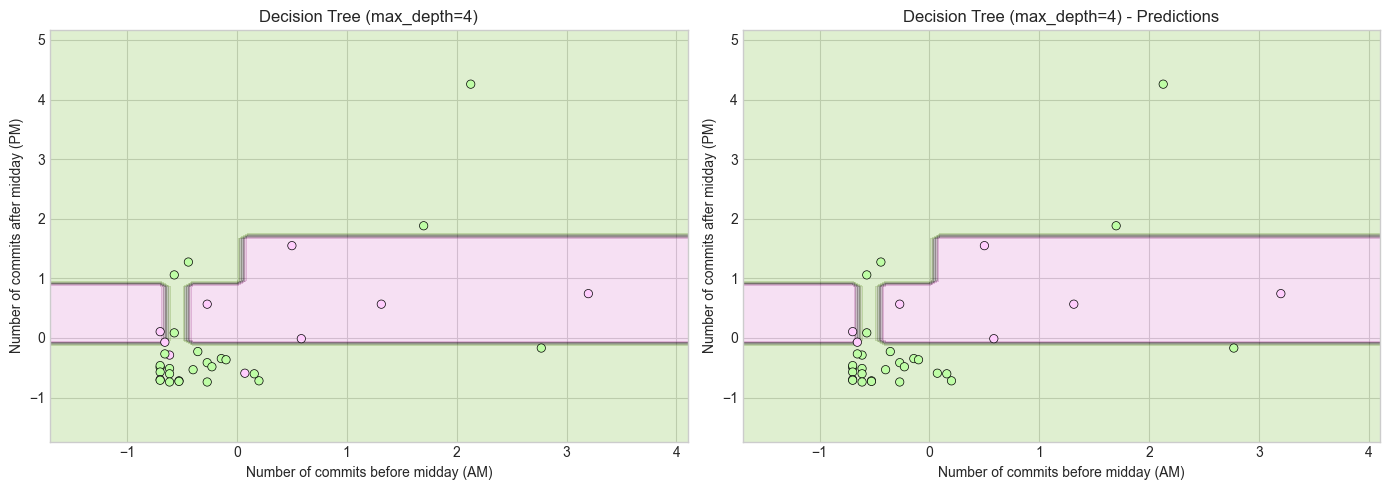

In [89]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_decision_boundary(X_scaled, y, dt,
                       "Decision Tree (max_depth=4)", ax=ax1)
plot_decision_boundary(X_scaled, dt.predict(X_scaled), dt,
                       "Decision Tree (max_depth=4) - Predictions", ax=ax2)

plt.tight_layout()
plt.show()

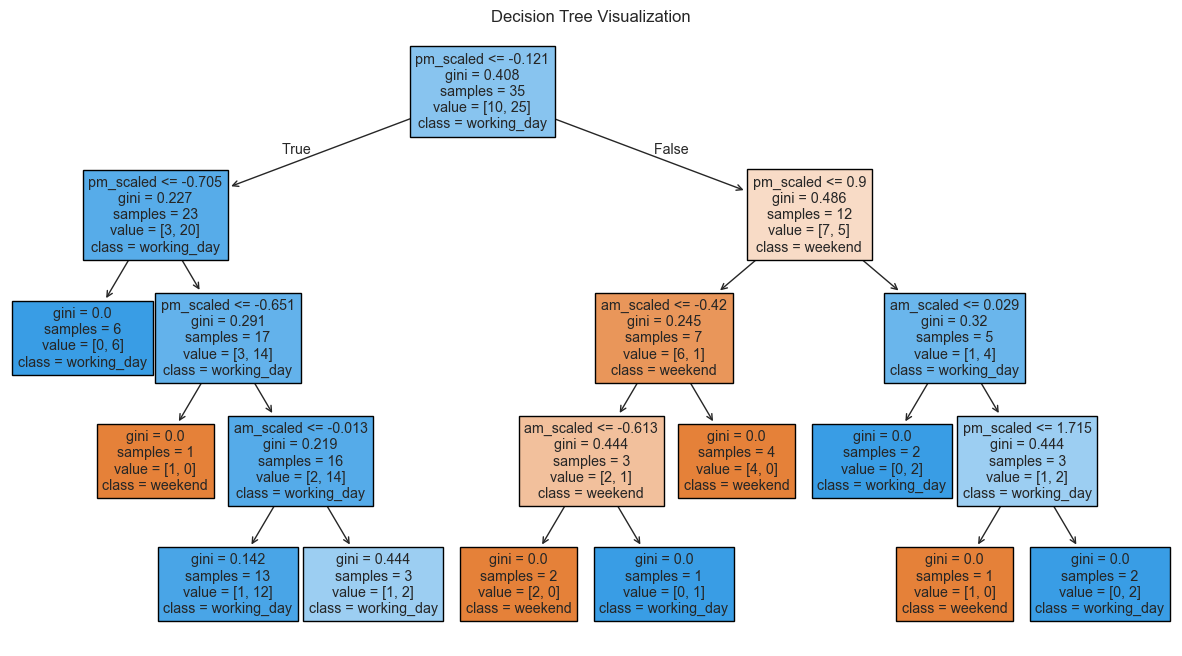

In [90]:
plt.figure(figsize=(15, 8))
plot_tree(dt, feature_names=['am_scaled', 'pm_scaled'],
          class_names=list(dt.classes_), filled=True)
plt.title("Decision Tree Visualization")
plt.show()

Number of leaves that predict 'weekend' days: 4